##Install PySpark and Other Needed Libraries

In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.4.1-py2.py3-none-any.whl size=311285398 sha256=bfb02ad0f1687a1427e3489975351d0e9850562180364da26f7e6635c41dffc3
  Stored in directory: /root/.cache/pip/wheels/0d/77/a3/ff2f74cc9ab41f8f594dabf0579c2a7c6de920d584206e0834
Successfully built pyspark


In [2]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import col
from sklearn.preprocessing import MinMaxScaler

In [3]:
import datetime
from math import ceil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

The Dataset

In [4]:
telemetry_df = pd.read_csv('/content/drive/MyDrive/PdM_telemetry.csv')
telemetry_df.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [5]:
telemetry_df[['volt', 'rotate', 'pressure', 'vibration']].describe()

,volt,rotate,pressure,vibration
count,876100.000000,876100.000000,876100.000000,876100.000000
mean,170.777736,446.605119,100.858668,40.385007
std,15.509114,52.673886,11.048679,5.370361
min,97.333604,138.432075,51.237106,14.877054
25%,160.304927,412.305714,93.498181,36.777299
50%,170.607338,447.558150,100.425559,40.237247
75%,181.004493,482.176600,107.555231,43.784938
max,255.124717,695.020984,185.951998,76.791072


Data info

In [6]:
telemetry_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  object 
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ MB


##Preprocessing

Adding failure column

In [7]:
failures = pd.read_csv('/content/drive/MyDrive/PdM_failures.csv')
failures.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [8]:
failures = failures.sort_values(by='datetime')
failures.reset_index(inplace=True, drop=True)
failures.head()

,datetime,machineID,failure
0,2015-01-02 03:00:00,56,comp3
1,2015-01-02 03:00:00,99,comp3
2,2015-01-02 03:00:00,83,comp4
3,2015-01-02 03:00:00,59,comp1
4,2015-01-02 03:00:00,16,comp1


In [9]:
telemetry_with_failure_df = telemetry_df.merge(failures, on=['datetime', 'machineID'], how='left')
telemetry_with_failure_df.fillna('No Failure', inplace=True)

In [10]:
telemetry_with_failure_df['failure'].value_counts()

No Failure    875381
comp2            259
comp1            192
comp4            179
comp3            131
Name: failure, dtype: int64

Adding the model and age columns

In [11]:
machine_info = pd.read_csv('/content/drive/MyDrive/PdM_machines.csv')
machine_info.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [12]:
telemetry_with_failure_df = machine_info.merge(right=telemetry_with_failure_df, on=['machineID'], how='left')
telemetry_with_failure_df.head()

,machineID,model,age,datetime,volt,rotate,pressure,vibration,failure
0,1,model3,18,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,No Failure
1,1,model3,18,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,No Failure
2,1,model3,18,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,No Failure
3,1,model3,18,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,No Failure
4,1,model3,18,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,No Failure


In [13]:
telemetry_with_failure_df['model'].value_counts()

model3    306644
model4    280363
model2    148945
model1    140190
Name: model, dtype: int64

Datetime column type casting

In [14]:
def strToDatetime(date_array, format):
    new_datetime = list()
    for date in date_array:
        new_datetime.append(datetime.datetime.strptime(date, format))
    return new_datetime

In [15]:
datetime_column = strToDatetime(telemetry_with_failure_df['datetime'], '%Y-%m-%d %H:%M:%S')


In [16]:
telemetry_with_failure_df['datetime'] = datetime_column


In [17]:
telemetry_with_failure_df['datetime'].min(), telemetry_with_failure_df['datetime'].max()

(Timestamp('2015-01-01 06:00:00'), Timestamp('2016-01-01 06:00:00'))

Time to failure estimation

In [18]:
machine_ids = np.arange(1, 101)
len(machine_ids)

100

In [19]:
def hours_estimation(machine_id):
    df = telemetry_with_failure_df[telemetry_with_failure_df['machineID'] == machine_id]
    df.reset_index(drop=True, inplace=True)
    rul = []
    cont = len(df['failure']) - 1
    diff = 0
    while cont >= df.index.min():
        if df['failure'][cont] == 'No Failure':
            diff = diff + 1
            rul.append(diff)
        else:
            rul.append(0)
            diff = 0
        diff = rul[-1]
        cont = cont - 1
    df['hours_to_fail'] = list(reversed(rul))
    return df

In [20]:
dfs = []
for machine_id in machine_ids:
    df = hours_estimation(machine_id)
    dfs.append(df)

In [21]:
telemetry = pd.DataFrame()
for df in dfs:
    telemetry = pd.concat([telemetry, df], axis=0)

In [22]:
print(telemetry.shape[0], telemetry_with_failure_df.shape[0])

876142 876142


In [23]:
telemetry['seconds_to_fail'] = telemetry['hours_to_fail'] * 3600
telemetry.drop('hours_to_fail', axis=1, inplace=True)
telemetry.head()

,machineID,model,age,datetime,volt,rotate,pressure,vibration,failure,seconds_to_fail
0,1,model3,18,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,No Failure,345600
1,1,model3,18,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,No Failure,342000
2,1,model3,18,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,No Failure,338400
3,1,model3,18,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,No Failure,334800
4,1,model3,18,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,No Failure,331200


Choosing the machine model for the LR

In [24]:
model3_data = telemetry[telemetry['model'] == 'model3'].reset_index(drop=True)

In [25]:
def create_time_step(data, machine_id):
    machine_id_data = data[data['machineID'] == machine_id]
    time_step = np.arange(1, machine_id_data.shape[0]+1)
    machine_id_data['time_step'] = time_step
    return machine_id_data

In [26]:
machineIDs = model3_data['machineID'].unique()
dataframes_with_time_step = []
for machine_id in machineIDs:
    dataframes_with_time_step.append(create_time_step(model3_data, machine_id))
len(dataframes_with_time_step)

35

In [27]:
model3_data = pd.DataFrame()
for df in dataframes_with_time_step:
    model3_data = pd.concat([model3_data, df])

In [28]:
model3_data

,machineID,model,age,datetime,volt,rotate,pressure,vibration,failure,seconds_to_fail,time_step
0,1,model3,18,2015-01-01 06:00:00,176.217853,418.504078,113.077935,45.087686,No Failure,345600,1
1,1,model3,18,2015-01-01 07:00:00,162.879223,402.747490,95.460525,43.413973,No Failure,342000,2
2,1,model3,18,2015-01-01 08:00:00,170.989902,527.349825,75.237905,34.178847,No Failure,338400,3
3,1,model3,18,2015-01-01 09:00:00,162.462833,346.149335,109.248561,41.122144,No Failure,334800,4
4,1,model3,18,2015-01-01 10:00:00,157.610021,435.376873,111.886648,25.990511,No Failure,331200,5
...,...,...,...,...,...,...,...,...,...,...,...
306639,93,model3,18,2016-01-01 02:00:00,202.858467,412.870855,85.569847,47.701614,No Failure,18000,8757
306640,93,model3,18,2016-01-01 03:00:00,171.364527,459.880473,94.316793,47.592136,No Failure,14400,8758
306641,93,model3,18,2016-01-01 04:00:00,182.867119,491.584480,90.332643,58.592710,No Failure,10800,8759
306642,93,model3,18,2016-01-01 05:00:00,166.943545,352.047138,82.068954,46.256361,No Failure,7200,8760


###normalize

Removing unecessary columns

In [29]:
scaler = MinMaxScaler()

model3 = model3_data.drop(['model', 'failure', 'datetime', 'machineID'], axis=1)

normalized_telemetry = pd.DataFrame(data=scaler.fit_transform(model3), columns=model3.columns)
normalized_telemetry.head()

,age,volt,rotate,pressure,vibration,seconds_to_fail,time_step
0,0.894737,0.510638,0.469652,0.472451,0.476569,0.010958,0.000000
1,0.894737,0.421045,0.439431,0.337821,0.448935,0.010844,0.000114
2,0.894737,0.475523,0.678413,0.183282,0.296461,0.010729,0.000228
3,0.894737,0.418248,0.330878,0.443188,0.411097,0.010615,0.000342
4,0.894737,0.385652,0.502013,0.463348,0.161269,0.010501,0.000457


In [30]:
normalized_telemetry

,age,volt,rotate,pressure,vibration,seconds_to_fail,time_step
0,0.894737,0.510638,0.469652,0.472451,0.476569,0.010958,0.000000
1,0.894737,0.421045,0.439431,0.337821,0.448935,0.010844,0.000114
2,0.894737,0.475523,0.678413,0.183282,0.296461,0.010729,0.000228
3,0.894737,0.418248,0.330878,0.443188,0.411097,0.010615,0.000342
4,0.894737,0.385652,0.502013,0.463348,0.161269,0.010501,0.000457
...,...,...,...,...,...,...,...
306639,0.894737,0.689578,0.458847,0.262238,0.519725,0.000571,0.999315
306640,0.894737,0.478039,0.549010,0.329081,0.517918,0.000457,0.999429
306641,0.894737,0.555300,0.609817,0.298634,0.699540,0.000342,0.999543
306642,0.894737,0.448344,0.342190,0.235484,0.495864,0.000228,0.999658


#Spark

In [31]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark

In [32]:
spark_model3 = spark.createDataFrame(model3_data)

In [33]:
spark_model3.show()

+---------+------+---+-------------------+----------------+----------------+----------------+----------------+----------+---------------+---------+
|machineID| model|age|           datetime|            volt|          rotate|        pressure|       vibration|   failure|seconds_to_fail|time_step|
+---------+------+---+-------------------+----------------+----------------+----------------+----------------+----------+---------------+---------+
|        1|model3| 18|2015-01-01 06:00:00|176.217853015625|418.504078221616|113.077935462083|45.0876857639276|No Failure|         345600|        1|
|        1|model3| 18|2015-01-01 07:00:00| 162.87922289706|402.747489565395|95.4605253823187|43.4139726834815|No Failure|         342000|        2|
|        1|model3| 18|2015-01-01 08:00:00|170.989902405567|527.349825452291|75.2379048586662|34.1788471214451|No Failure|         338400|        3|
|        1|model3| 18|2015-01-01 09:00:00|162.462833264092|346.149335043074|109.248561276504|41.1221440884256|No

In [34]:
def shape(data):
  num_row = data.count()
  num_columns = len(data.columns)
  return (num_row, num_columns)

shape(spark_model3)

(306644, 11)

In [35]:
spark_model3.printSchema()

root
 |-- machineID: long (nullable = true)
 |-- model: string (nullable = true)
 |-- age: long (nullable = true)
 |-- datetime: timestamp (nullable = true)
 |-- volt: double (nullable = true)
 |-- rotate: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- vibration: double (nullable = true)
 |-- failure: string (nullable = true)
 |-- seconds_to_fail: long (nullable = true)
 |-- time_step: long (nullable = true)



In [36]:
spark_model3 = spark_model3.drop('model', 'failure', 'datetime', 'machineID')

In [37]:
spark_model3.show()

+---+----------------+----------------+----------------+----------------+---------------+---------+
|age|            volt|          rotate|        pressure|       vibration|seconds_to_fail|time_step|
+---+----------------+----------------+----------------+----------------+---------------+---------+
| 18|176.217853015625|418.504078221616|113.077935462083|45.0876857639276|         345600|        1|
| 18| 162.87922289706|402.747489565395|95.4605253823187|43.4139726834815|         342000|        2|
| 18|170.989902405567|527.349825452291|75.2379048586662|34.1788471214451|         338400|        3|
| 18|162.462833264092|346.149335043074|109.248561276504|41.1221440884256|         334800|        4|
| 18| 157.61002119306|435.376873016938|111.886648210168|25.9905109982024|         331200|        5|
| 18|172.504839196295|430.323362106675|95.9270416939636|35.6550173268837|         327600|        6|
| 18|156.556030606329|499.071623068962|111.755684290096|42.7539196974773|         324000|        7|


In [38]:
spark_model3.printSchema()

root
 |-- age: long (nullable = true)
 |-- volt: double (nullable = true)
 |-- rotate: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- vibration: double (nullable = true)
 |-- seconds_to_fail: long (nullable = true)
 |-- time_step: long (nullable = true)



In [39]:
spark_model3.columns

['age',
 'volt',
 'rotate',
 'pressure',
 'vibration',
 'seconds_to_fail',
 'time_step']

In [40]:
shape(spark_model3)

(306644, 7)

##Define Features and Target

In [41]:
from pyspark.ml.feature import VectorAssembler

vectorassembeler = VectorAssembler(inputCols=['age',
 'volt',
 'rotate',
 'pressure',
 'vibration',
 'time_step'], outputCol='features')

vdata = vectorassembeler.transform(spark_model3)
vdata = vdata.select(['features', 'seconds_to_fail'])

In [42]:
vdata.show()

+--------------------+---------------+
|            features|seconds_to_fail|
+--------------------+---------------+
|[18.0,176.2178530...|         345600|
|[18.0,162.8792228...|         342000|
|[18.0,170.9899024...|         338400|
|[18.0,162.4628332...|         334800|
|[18.0,157.6100211...|         331200|
|[18.0,172.5048391...|         327600|
|[18.0,156.5560306...|         324000|
|[18.0,172.5227808...|         320400|
|[18.0,175.3245239...|         316800|
|[18.0,169.2184232...|         313200|
|[18.0,167.0609807...|         309600|
|[18.0,160.2639537...|         306000|
|[18.0,153.3534915...|         302400|
|[18.0,182.7391130...|         298800|
|[18.0,170.3354378...|         295200|
|[18.0,182.4671092...|         291600|
|[18.0,151.3356822...|         288000|
|[18.0,172.5353962...|         284400|
|[18.0,180.0974946...|         280800|
|[18.0,169.6058543...|         277200|
+--------------------+---------------+
only showing top 20 rows



##Train & Test split

In [43]:
split_index = int(vdata.count() * 0.7)
training_data = vdata.limit(split_index)
testing_data = vdata.subtract(training_data)

In [44]:
shape(training_data)

(214650, 2)

In [45]:
shape(testing_data)

(91994, 2)

#Creating and Training the Model

In [46]:
from pyspark.ml.regression import LinearRegression

model = LinearRegression(labelCol= 'seconds_to_fail', featuresCol='features')
model_trained = model.fit(training_data)

##Evaluation

In [47]:
# model intercept
model_trained.intercept

8734470.911098445

In [48]:
# coefficient
coeff = model_trained.coefficients.toArray()
coeff

array([-167893.21450727,   -4787.48624146,    1455.72068446,
         -1538.8995007 ,  -17322.37895262,    -356.54567219])

##Prediction using the Model

In [49]:
# prediction on test set

predictions = model_trained.transform(testing_data)
predictions.show()

+--------------------+---------------+------------------+
|            features|seconds_to_fail|        prediction|
+--------------------+---------------+------------------+
|[15.0,123.3408010...|        3632400| 3786599.087784961|
|[15.0,152.9951006...|        2955600|3739465.1702937316|
|[15.0,173.5545584...|        2844000|3559161.2528845547|
|[15.0,208.9288708...|        2138400|3275732.7144028544|
|[15.0,164.7983625...|        1724400| 3380762.503493283|
|[15.0,169.0124030...|        1461600|3396728.9893630277|
|[15.0,183.9829984...|        1260000| 3268780.225379044|
|[15.0,196.9493118...|        1242000| 3332885.537128133|
|[15.0,168.3629609...|         774000|3579174.4068400133|
|[15.0,164.3414188...|         676800|3637491.6273863893|
|[15.0,150.7833122...|         388800|3283648.4869513754|
|[15.0,168.4102494...|         324000| 3346078.916685651|
|[15.0,168.4576051...|         205200|3123796.2309691636|
|[15.0,185.7483042...|         172800|3006731.9905646965|
|[15.0,156.318

###Regression Evaluation Metrics

In [50]:
from pyspark.ml.evaluation import RegressionEvaluator

#mae
evaluator = RegressionEvaluator(labelCol = 'seconds_to_fail', metricName = 'mae')
mae = evaluator.evaluate(predictions)

#mse
evaluator = RegressionEvaluator(labelCol = 'seconds_to_fail', metricName = 'mse')
mse = evaluator.evaluate(predictions)

#rmse
evaluator = RegressionEvaluator(labelCol = 'seconds_to_fail', metricName = 'rmse')
rmse = evaluator.evaluate(predictions)


print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 2913941.8160534715
Mean Squared Error: 14276962732220.557
Root Mean Squared Error: 3778486.831023837


In [51]:
df_to_plot = predictions.toPandas()

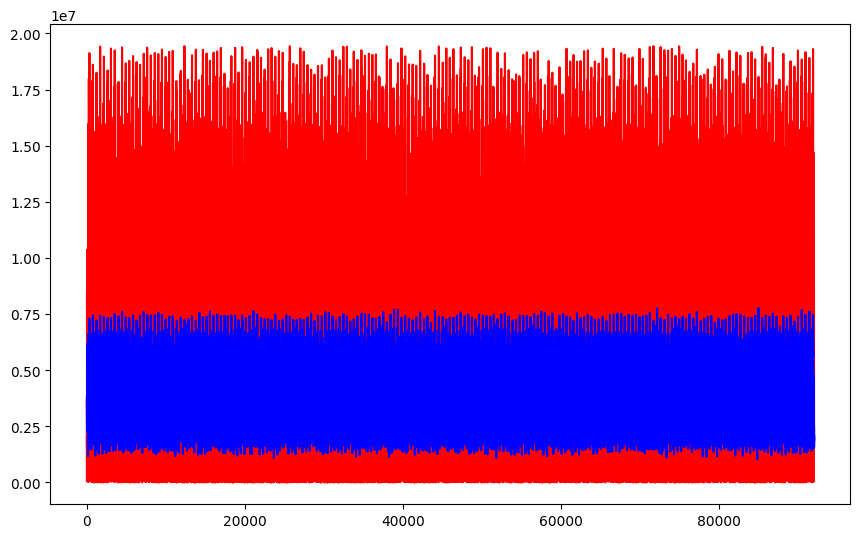

In [52]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 6)
ax.set_position([0.1, 0.1, 0.8, 0.8])
plt.plot(df_to_plot['seconds_to_fail'], color='red')
plt.plot(df_to_plot['prediction'], color='blue')
plt.show()

#Doing Project Again With Normalized Data

In [53]:
from pyspark.sql import SparkSession
spark2 = SparkSession.builder.master("local[*]").getOrCreate()
spark2

In [54]:
norm_spark_model3 = spark2.createDataFrame(normalized_telemetry)

In [55]:
norm_spark_model3.show()

+-----------------+-------------------+-------------------+-------------------+-------------------+--------------------+--------------------+
|              age|               volt|             rotate|           pressure|          vibration|     seconds_to_fail|           time_step|
+-----------------+-------------------+-------------------+-------------------+-------------------+--------------------+--------------------+
|0.894736842105263|  0.510638005263428| 0.4696515292705279|0.47245121852040034| 0.4765687927329931|0.010957653235931971|                 0.0|
|0.894736842105263| 0.4210447591348411|  0.439431016488403| 0.3378209561265804| 0.4489353518299694|0.010843511014724347|1.141291942478886...|
|0.894736842105263| 0.4755227751692138| 0.6784133600977775| 0.1832819691209257| 0.2964610123317581|0.010729368793516722|2.282583884957772E-4|
|0.894736842105263| 0.4182479427796165|0.33087799847766863| 0.4431875725545957| 0.4110966620442284|0.010615226572309098|3.423875827436658E-4|
|0.894

In [56]:
norm_spark_model3.printSchema()

root
 |-- age: double (nullable = true)
 |-- volt: double (nullable = true)
 |-- rotate: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- vibration: double (nullable = true)
 |-- seconds_to_fail: double (nullable = true)
 |-- time_step: double (nullable = true)



In [57]:
shape(norm_spark_model3)

(306644, 7)

preprocessing

In [58]:
norm_spark_model3 = norm_spark_model3.withColumnRenamed('age', 'norm_age')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('volt', 'norm_volt')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('rotate', 'norm_rotate')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('pressure', 'norm_pressure')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('vibration', 'norm_vibration')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('time_step', 'norm_time_step')
norm_spark_model3 = norm_spark_model3.withColumnRenamed('seconds_to_fail', 'norm_seconds_to_fail')

Features and Target

In [59]:
vectorassembeler2 = VectorAssembler(inputCols=['norm_age',
 'norm_volt',
 'norm_rotate',
 'norm_pressure',
 'norm_vibration',
 'norm_time_step'], outputCol='norm_features')

norm_vdata = vectorassembeler2.transform(norm_spark_model3)
norm_vdata = norm_vdata.select(['norm_features', 'norm_seconds_to_fail'])

In [60]:
norm_vdata.show()

+--------------------+--------------------+
|       norm_features|norm_seconds_to_fail|
+--------------------+--------------------+
|[0.89473684210526...|0.010957653235931971|
|[0.89473684210526...|0.010843511014724347|
|[0.89473684210526...|0.010729368793516722|
|[0.89473684210526...|0.010615226572309098|
|[0.89473684210526...|0.010501084351101473|
|[0.89473684210526...|0.010386942129893849|
|[0.89473684210526...|0.010272799908686224|
|[0.89473684210526...|  0.0101586576874786|
|[0.89473684210526...|0.010044515466270974|
|[0.89473684210526...|0.009930373245063349|
|[0.89473684210526...|0.009816231023855725|
|[0.89473684210526...|  0.0097020888026481|
|[0.89473684210526...|0.009587946581440476|
|[0.89473684210526...|0.009473804360232851|
|[0.89473684210526...|0.009359662139025227|
|[0.89473684210526...|0.009245519917817602|
|[0.89473684210526...|0.009131377696609978|
|[0.89473684210526...|0.009017235475402351|
|[0.89473684210526...|0.008903093254194727|
|[0.89473684210526...|0.00878895

Test and Train split

In [61]:
split_index = int(vdata.count() * 0.7)
norm_training_data = norm_vdata.limit(split_index)
norm_testing_data = norm_vdata.subtract(norm_training_data)

model define

In [62]:
model2 = LinearRegression(labelCol= 'norm_seconds_to_fail', featuresCol='norm_features')
norm_model_trained = model2.fit(norm_training_data)

Evaluation

In [63]:
# model intercept
norm_model_trained.intercept

0.25299671353438463

In [64]:
# coefficient
coeff = norm_model_trained.coefficients.toArray()
coeff

array([-0.10114177, -0.0225989 ,  0.0240648 , -0.00638489, -0.03326576,
       -0.09905177])

Prediction

In [65]:
# prediction on test set

predictions_for_norm = norm_model_trained.transform(norm_testing_data)
predictions_for_norm.show()

+--------------------+--------------------+-------------------+
|       norm_features|norm_seconds_to_fail|         prediction|
+--------------------+--------------------+-------------------+
|[0.73684210526315...| 0.11322908343796372|0.11244401881355012|
|[0.73684210526315...|  0.0900582125328159|0.11919839833334364|
|[0.73684210526315...| 0.06643077274283758|0.11092824404664761|
|[0.73684210526315...| 0.06494692386713846|0.10933043601836595|
|[0.73684210526315...| 0.03698207967127041| 0.1047542789998459|
|[0.73684210526315...|0.018376897614427578|0.10647380161406675|
|[0.73684210526315...|0.005707111060381...|0.10594212578586115|
|[0.73684210526315...|  0.0798995548453373|0.09932223092331924|
|[0.73684210526315...|0.041547768519575395|0.08998727588383112|
|[0.73684210526315...|0.026823421983791805|0.10212917730082527|
|[0.73684210526315...| 0.25761899326560894|0.09459446589600468|
|[0.73684210526315...|  0.2042004337404406|0.08682445853291565|
|[0.73684210526315...| 0.185366967241182

Regression Metrics

In [66]:
#mae
evaluator = RegressionEvaluator(labelCol = 'norm_seconds_to_fail', metricName = 'mae')
mae = evaluator.evaluate(predictions_for_norm)

#mse
evaluator = RegressionEvaluator(labelCol = 'norm_seconds_to_fail', metricName = 'mse')
mse = evaluator.evaluate(predictions_for_norm)

#rmse
evaluator = RegressionEvaluator(labelCol = 'norm_seconds_to_fail', metricName = 'rmse')
rmse = evaluator.evaluate(predictions_for_norm)


print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 0.09238994204282698
Mean Squared Error: 0.014352364772768174
Root Mean Squared Error: 0.11980135547133085


Plot

In [67]:
predictions_for_norm_half = predictions_for_norm.sample(fraction=0.5, seed=42)

In [68]:
df_to_plot = predictions_for_norm_half.toPandas()

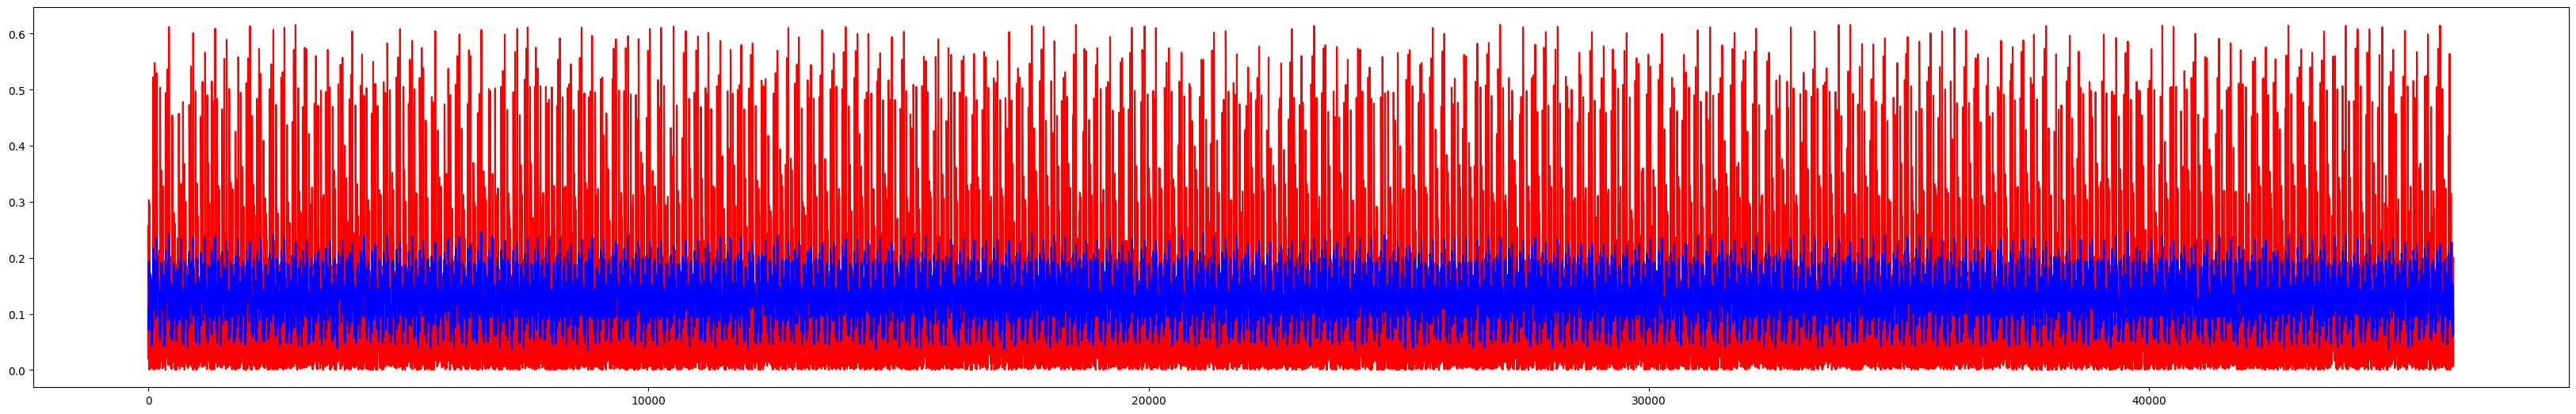

In [69]:
fig, ax = plt.subplots()
fig.set_size_inches(40, 6)
ax.set_position([0.1, 0.1, 0.8, 0.8])
plt.plot(df_to_plot['norm_seconds_to_fail'], color='red')
plt.plot(df_to_plot['prediction'], color='blue')
plt.show()